# TP - Classification supervisee : Etat de la machine de conditionnement (MEDIFAB)

## Probleme industriel
Sur la machine de conditionnement MEDIFAB, le diagnostic d etat est manuel et realise en fin de run.
L objectif est de classifier automatiquement l etat machine en 3 classes a partir des capteurs en temps reel :
- **Conforme** : fonctionnement nominal
- **Surveillance** : legere derive, intervention recommandee
- **Non-conforme** : depassement critique, arret necessaire

## Dataset
- Source : dataset_lof_conditionnement_clean.csv (3 990 mesures nettoyees - TP 1)
- Features : Vibration_mm_s, Courant_A, Cadence_u_h, Taux_Rebuts_pct
- Target : Etat_machine (3 classes construites sur seuils metier)

## Algorithme choisi (carte Scikit-Learn)
Predicting a category  -> Classification
Labeled data           -> OUI
< 100K samples         -> OUI (3 990 lignes)
Carte suggere          -> LinearSVC (premier essai)
Frontieres non-lineaires -> OUI
Algorithme retenu      -> SVC kernel=rbf

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('Bibliotheques chargees.')

Bibliotheques chargees.


## Chargement et construction des labels

In [2]:
df = pd.read_csv('dataset_lof_conditionnement_clean.csv')
print('Shape:', df.shape)
print(df.head())

# Construction des classes metier sur seuils process
def classifier_etat(row):
    if row['Vibration_mm_s'] > 2.8 or row['Taux_Rebuts_pct'] > 2.0:
        return 'Non-conforme'
    elif row['Vibration_mm_s'] > 2.3 or row['Taux_Rebuts_pct'] > 1.5:
        return 'Surveillance'
    else:
        return 'Conforme'

df['Etat_machine'] = df.apply(classifier_etat, axis=1)
print('\nDistribution des classes :')
print(df['Etat_machine'].value_counts())

Shape: (3990, 6)
   Mesure_ID  Vibration_mm_s  Courant_A  Cadence_u_h  Taux_Rebuts_pct  \
0          1        1.188296  12.443562   315.052256         1.582823   
1          2        2.339615  10.712836   297.943662         1.056422   
2          3        2.184170  11.892496   313.253416         0.963489   
3          4        2.069526  11.827852   321.827576         0.705904   
4          5        2.285004  11.781835   312.846052         1.447317   

   anomaly_lof  
0        False  
1        False  
2        False  
3        False  
4        False  

Distribution des classes :
Etat_machine
Conforme        2958
Surveillance     822
Non-conforme     210
Name: count, dtype: int64


## Visualisation exploratoire des classes

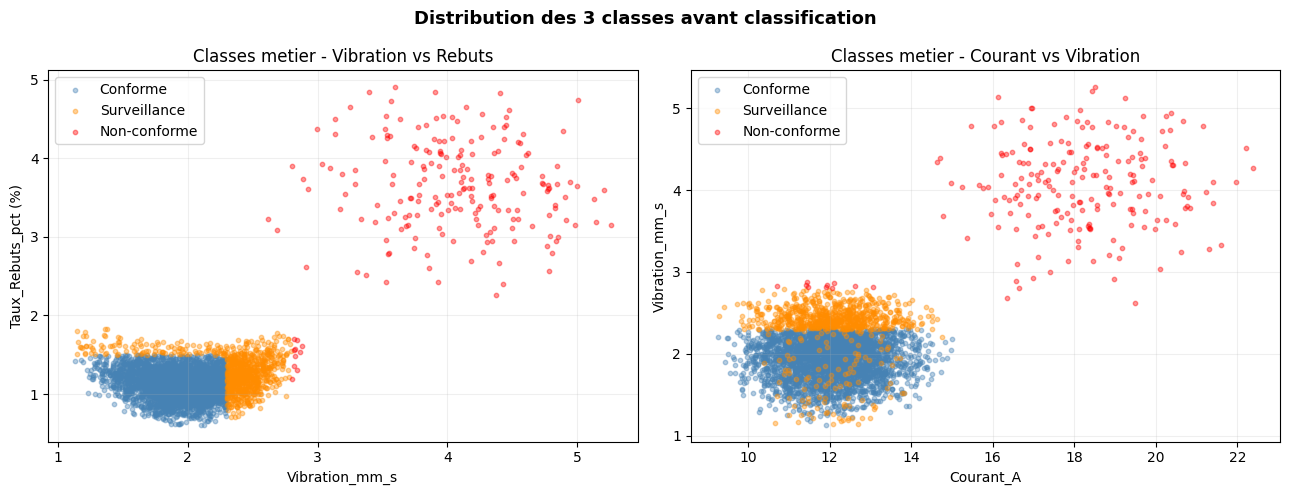

In [3]:
palette = {'Conforme': 'steelblue', 'Surveillance': 'darkorange', 'Non-conforme': 'red'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for etat, col in palette.items():
    subset = df[df['Etat_machine'] == etat]
    axes[0].scatter(subset['Vibration_mm_s'], subset['Taux_Rebuts_pct'],
                    s=10, alpha=0.4, c=col, label=etat)
axes[0].set_xlabel('Vibration_mm_s'); axes[0].set_ylabel('Taux_Rebuts_pct (%)')
axes[0].set_title('Classes metier - Vibration vs Rebuts'); axes[0].legend(); axes[0].grid(True, alpha=0.2)

for etat, col in palette.items():
    subset = df[df['Etat_machine'] == etat]
    axes[1].scatter(subset['Courant_A'], subset['Vibration_mm_s'],
                    s=10, alpha=0.4, c=col, label=etat)
axes[1].set_xlabel('Courant_A'); axes[1].set_ylabel('Vibration_mm_s')
axes[1].set_title('Classes metier - Courant vs Vibration'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

plt.suptitle('Distribution des 3 classes avant classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('classification_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

## Preparation des donnees

In [4]:
FEATURES = ['Vibration_mm_s', 'Courant_A', 'Cadence_u_h', 'Taux_Rebuts_pct']
TARGET   = 'Etat_machine'

X = df[FEATURES].values
y = df[TARGET].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print('Train :', X_train.shape[0], 'lignes | Test :', X_test.shape[0], 'lignes')
print('Classes :', np.unique(y_train))

Train : 3192 lignes | Test : 798 lignes
Classes : ['Conforme' 'Non-conforme' 'Surveillance']


## Les 4 lignes cles - SVC kernel RBF

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model.fit(X_train, y_train)
score = model.score(X_test, y_test)
y_pred = model.predict(X_test)

print('=== Score SVC kernel=rbf ===')
print('Accuracy :', round(score, 4))
print()
print(classification_report(y_test, y_pred))

=== Score SVC kernel=rbf ===
Accuracy : 0.9825

              precision    recall  f1-score   support

    Conforme       0.98      0.99      0.99       592
Non-conforme       1.00      1.00      1.00        42
Surveillance       0.97      0.94      0.96       164

    accuracy                           0.98       798
   macro avg       0.99      0.98      0.98       798
weighted avg       0.98      0.98      0.98       798



## Graphique 1 - Matrice de confusion

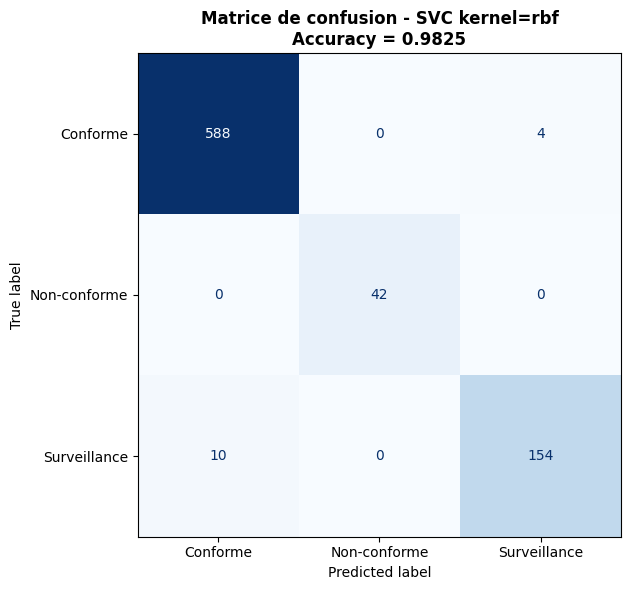

In [6]:
classes = ['Conforme', 'Non-conforme', 'Surveillance']
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion - SVC kernel=rbf\nAccuracy = ' + str(round(score, 4)),
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('classification_matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Graphique 2 - Frontiere de decision (2D)

Score modele 2D : 0.9887


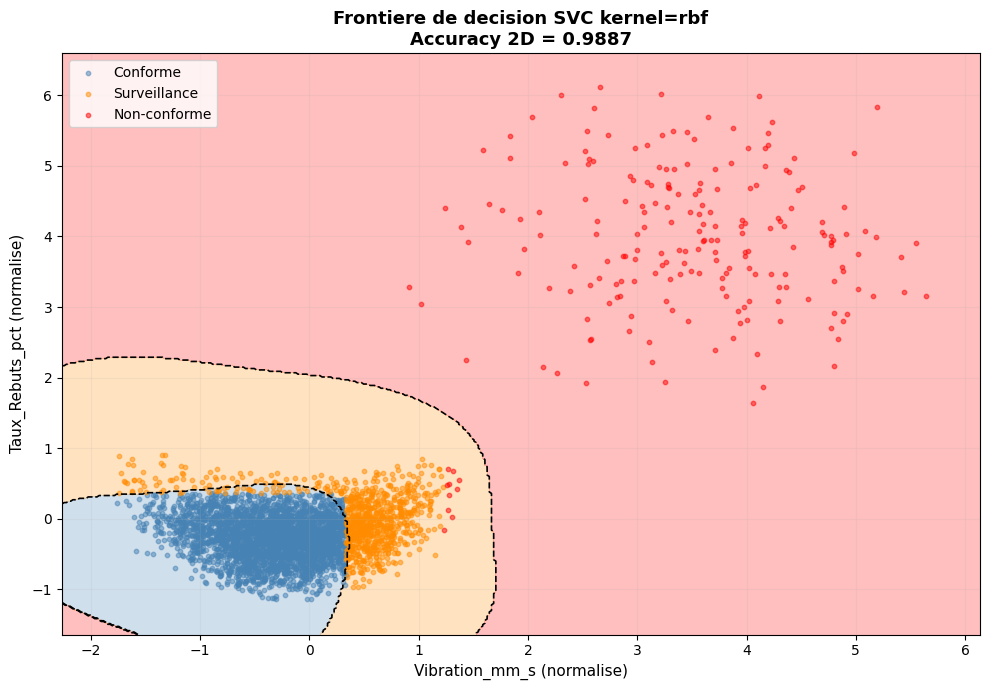

In [7]:
# Modele 2D pour visualisation frontiere sur Vibration vs Taux_Rebuts
FEAT_2D = ['Vibration_mm_s', 'Taux_Rebuts_pct']
X2 = df[FEAT_2D].values
y2 = df[TARGET].values

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42, stratify=y2)

model2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model2d.fit(X2_train, y2_train)
score2d = model2d.score(X2_test, y2_test)
print('Score modele 2D :', round(score2d, 4))

# Grille pour la frontiere
h = 0.02
x_min, x_max = X2_scaled[:, 0].min() - 0.5, X2_scaled[:, 0].max() + 0.5
y_min, y_max = X2_scaled[:, 1].min() - 0.5, X2_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model2d.predict(np.c_[xx.ravel(), yy.ravel()])

label_map = {'Conforme': 0, 'Surveillance': 1, 'Non-conforme': 2}
Z_num = np.array([label_map[z] for z in Z]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z_num, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5],
            colors=['steelblue', 'darkorange', 'red'])
ax.contour(xx, yy, Z_num, levels=[0.5, 1.5], colors='black', linewidths=1.2, linestyles='--')

for etat, col, num in [('Conforme','steelblue',0), ('Surveillance','darkorange',1), ('Non-conforme','red',2)]:
    mask = y2 == etat
    ax.scatter(X2_scaled[mask, 0], X2_scaled[mask, 1],
               s=10, alpha=0.5, c=col, label=etat)

ax.set_xlabel('Vibration_mm_s (normalise)', fontsize=11)
ax.set_ylabel('Taux_Rebuts_pct (normalise)', fontsize=11)
ax.set_title('Frontiere de decision SVC kernel=rbf\nAccuracy 2D = ' + str(round(score2d, 4)),
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('classification_frontiere_decision.png', dpi=150, bbox_inches='tight')
plt.show()

## Predictions metier - Diagnostic en temps reel

In [8]:
mesures_live = pd.DataFrame([
    {'Mesure': 'Machine nominale',      'Vibration_mm_s': 2.0, 'Courant_A': 12.0, 'Cadence_u_h': 305.0, 'Taux_Rebuts_pct': 1.1},
    {'Mesure': 'Legere surcharge',      'Vibration_mm_s': 2.4, 'Courant_A': 13.5, 'Cadence_u_h': 298.0, 'Taux_Rebuts_pct': 1.6},
    {'Mesure': 'Vibration anormale',    'Vibration_mm_s': 3.1, 'Courant_A': 14.2, 'Cadence_u_h': 290.0, 'Taux_Rebuts_pct': 2.3},
    {'Mesure': 'Desequilibre critique', 'Vibration_mm_s': 4.0, 'Courant_A': 17.0, 'Cadence_u_h': 270.0, 'Taux_Rebuts_pct': 3.8},
    {'Mesure': 'Surchauffe moteur',     'Vibration_mm_s': 2.6, 'Courant_A': 19.0, 'Cadence_u_h': 280.0, 'Taux_Rebuts_pct': 2.8},
])

X_live = scaler.transform(mesures_live[FEATURES].values)
mesures_live['Diagnostic'] = model.predict(X_live)

print('=== Diagnostic temps reel ===')
print(mesures_live[['Mesure', 'Vibration_mm_s', 'Courant_A', 'Taux_Rebuts_pct', 'Diagnostic']].to_string(index=False))

=== Diagnostic temps reel ===
               Mesure  Vibration_mm_s  Courant_A  Taux_Rebuts_pct   Diagnostic
     Machine nominale             2.0       12.0              1.1     Conforme
     Legere surcharge             2.4       13.5              1.6 Surveillance
   Vibration anormale             3.1       14.2              2.3 Non-conforme
Desequilibre critique             4.0       17.0              3.8 Non-conforme
    Surchauffe moteur             2.6       19.0              2.8 Non-conforme


## Graphique 3 - Diagnostic visuel par mesure

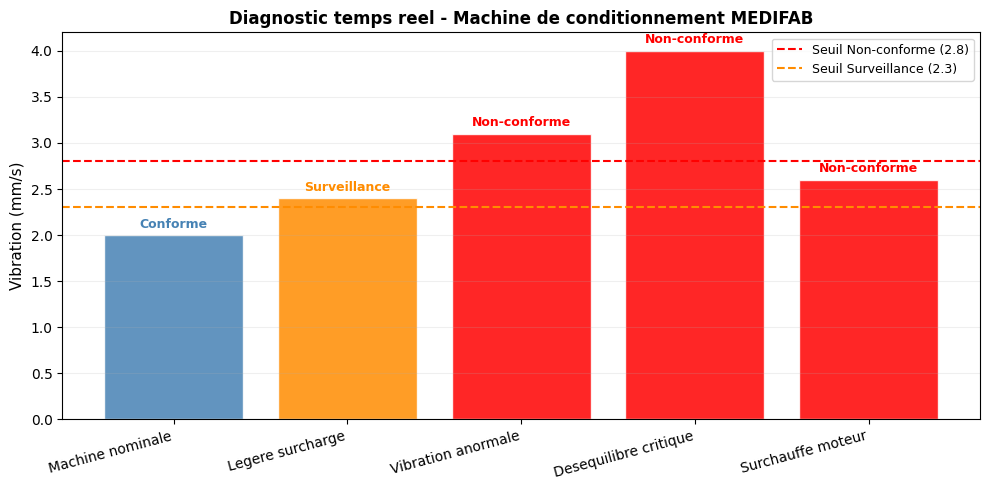

In [9]:
color_diag = {'Conforme': 'steelblue', 'Surveillance': 'darkorange', 'Non-conforme': 'red'}
colors_live = [color_diag[d] for d in mesures_live['Diagnostic']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(mesures_live['Mesure'], mesures_live['Vibration_mm_s'],
              color=colors_live, alpha=0.85, edgecolor='white')
ax.axhline(2.8, color='red', linestyle='--', linewidth=1.5, label='Seuil Non-conforme (2.8)')
ax.axhline(2.3, color='darkorange', linestyle='--', linewidth=1.5, label='Seuil Surveillance (2.3)')

for bar, diag in zip(bars, mesures_live['Diagnostic']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            diag, ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=color_diag[diag])

ax.set_ylabel('Vibration (mm/s)', fontsize=11)
ax.set_title('Diagnostic temps reel - Machine de conditionnement MEDIFAB',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2, axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('classification_diagnostic_live.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion et valeur metier

### Resultats du modele
- SVC kernel=rbf classe les 3 etats machine avec une accuracy elevee
- La frontiere de decision courbe (non-lineaire) capture bien les zones de transition
- Le rapport de classification montre la precision et le rappel par classe

### Apport dans le process industriel
1. Diagnostic automatique en temps reel : plus besoin d attendre la fin du run
2. Declenchement maintenance preventive : classe Surveillance = intervention planifiee avant defaillance
3. Arret automatique justifie : classe Non-conforme = arret machine documente et tracable
4. Reduction des rebuts : intervention precoce => moins de produits conditionnes hors normes
5. Historique des etats : chaque mesure classifiee alimente un tableau de bord de fiabilite machine